C:\Users\user\AppData\Local\Temp\ipykernel_13168\3495282671.py:119: FutureWarning: The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.
  n.optimize(solver_name="highs")
Index(['DK'], dtype='str', name='name')
Index(['Solar', 'Onshore Wind', 'Offshore Wind', 'Gas'], dtype='str', name='name')


2016-01-01 00:00:00 2016-12-31 23:00:00 8784

Solar CF sample:
utc_timestamp
2016-01-01 00:00:00    0.0
2016-01-01 01:00:00    0.0
2016-01-01 02:00:00    0.0
2016-01-01 03:00:00    0.0
2016-01-01 04:00:00    0.0
dtype: float64

Onshore Wind CF sample:
utc_timestamp
2016-01-01 00:00:00    0.239160
2016-01-01 01:00:00    0.203277
2016-01-01 02:00:00    0.200078
2016-01-01 03:00:00    0.199146
2016-01-01 04:00:00    0.211081
dtype: float64

Offshore Wind CF sample:
utc_timestamp
2016-01-01 00:00:00    0.397571
2016-01-01 01:00:00    0.395119
2016-01-01 02:00:00    0.394288
2016-01-01 03:00:00    0.316638
2016-01-01 04:00:00    0.227919
dtype: float64


INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 2/2 [00:00<00:00, 97.64it/s]
INFO:linopy.io: Writing time: 0.21s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 35140 primals, 79060 duals
Objective: 1.01e+12
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-ext-p-lower, Generator-ext-p-upper were not assigned to the network.



Optimal capacities (MW):
name
Solar                -0.000000
Onshore Wind     650227.733202
Offshore Wind    118616.872419
Gas                  -0.000000
Name: p_nom_opt, dtype: float64

Annual generation (MWh):
name
Solar            0.000000e+00
Onshore Wind     1.170164e+06
Offshore Wind    3.112601e+07
Gas              0.000000e+00
dtype: float64

Annual electricity mix (%):
name
Solar             0.000000
Onshore Wind      3.623229
Offshore Wind    96.376771
Gas               0.000000
dtype: float64

Capacity factors:
name
Solar                 NaN
Onshore Wind     0.000205
Offshore Wind    0.029873
Gas                   NaN
dtype: float64

Total system cost (€/year): 1011792687569.5154


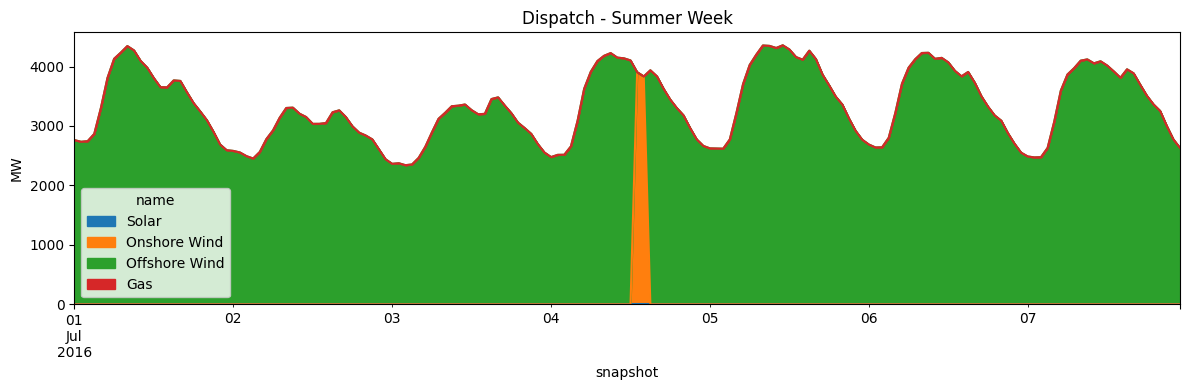

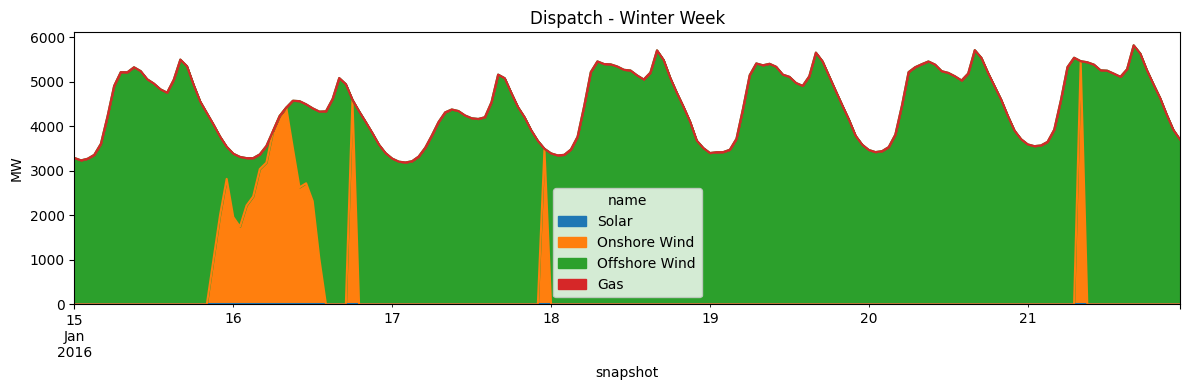

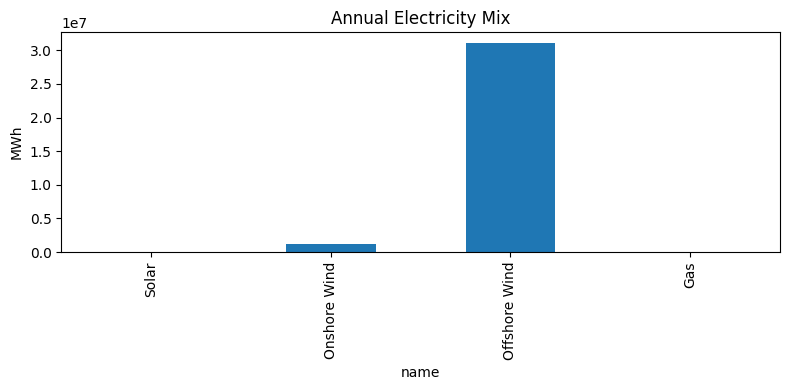

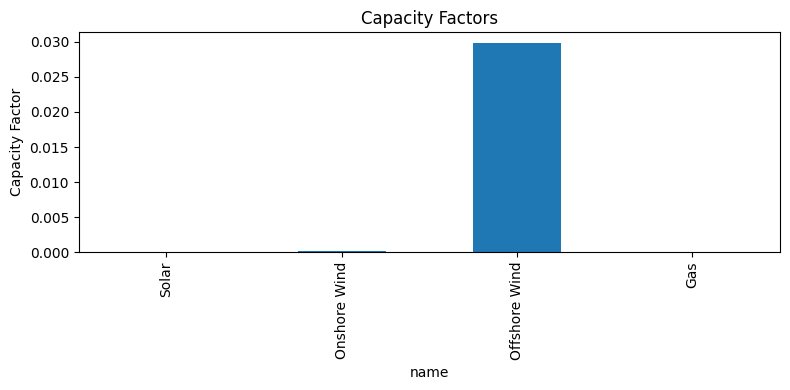

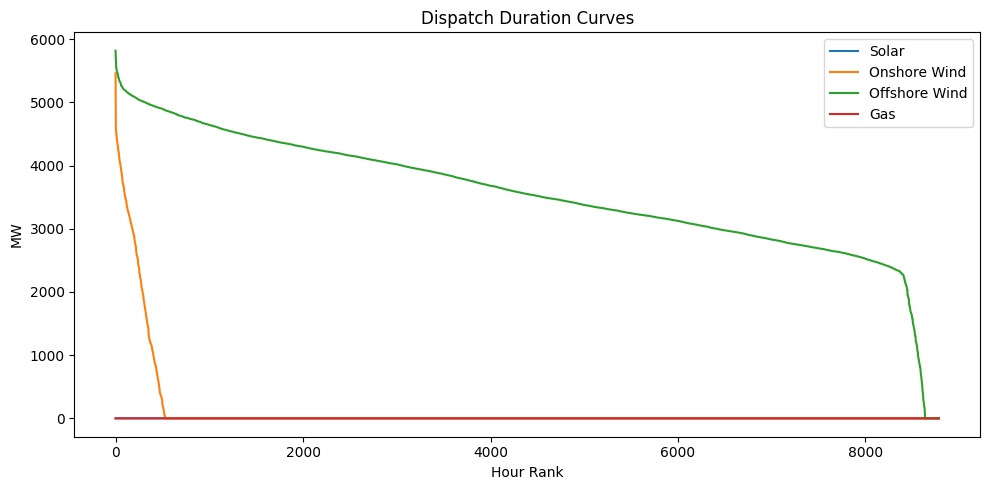

In [ ]:
import pypsa
import pandas as pd
import matplotlib.pyplot as plt


# 1. Read the data

df = pd.read_csv("Data/time_series_60min_singleindex_filtered_DK.csv")

df["utc_timestamp"] = pd.to_datetime(df["utc_timestamp"], utc=True)
df = df.set_index("utc_timestamp")
df.index = df.index.tz_localize(None)

# Keep only 2016
df = df.loc["2016-01-01":"2016-12-31"]


# 2. Build the time series

load_series = df["DK_load_actual_entsoe_transparency"]

solar_cf = (
    df["DK_solar_generation_actual"] / df["DK_solar_capacity"]
).fillna(0).clip(0, 1)

onwind_cf = (
    df["DK_wind_onshore_generation_actual"] / df["DK_wind_onshore_capacity"]
).fillna(0).clip(0, 1)

offwind_cf = (
    df["DK_wind_offshore_generation_actual"] / df["DK_wind_offshore_capacity"]
).fillna(0).clip(0, 1)

print(df.index.min(), df.index.max(), len(df))
#print the capacity factors to check they look reasonable
print("\nSolar CF sample:")
print(solar_cf.head())
print("\nOnshore Wind CF sample:")
print(onwind_cf.head())
print("\nOffshore Wind CF sample:")
print(offwind_cf.head())
# 3. Technology cost assumptions
# Replace these with your final referenced values
# -----------------------------
solar_capital_cost = 500000      # €/MW/year
onwind_capital_cost = 1100000    # €/MW/year
offwind_capital_cost = 2500000   # €/MW/year
gas_capital_cost = 1200000000       # €/MW/year
gas_marginal_cost = 60           # €/MWh

# -----------------------------
# 4. Create PyPSA network
# -----------------------------
n = pypsa.Network()
n.set_snapshots(df.index)

# One single node for Denmark
n.add("Bus", "DK", carrier="AC")

# Load
n.add(
    "Load",
    "Demand",
    bus="DK",
    p_set=load_series
)

# Solar
n.add(
    "Generator",
    "Solar",
    bus="DK",
    carrier="solar",
    p_nom_extendable=True,
    p_max_pu=solar_cf,
    capital_cost=solar_capital_cost,
    marginal_cost=0
)

# Onshore wind
n.add(
    "Generator",
    "Onshore Wind",
    bus="DK",
    carrier="onwind",
    p_nom_extendable=True,
    p_max_pu=onwind_cf,
    capital_cost=onwind_capital_cost,
    marginal_cost=0
)

# Offshore wind
n.add(
    "Generator",
    "Offshore Wind",
    bus="DK",
    carrier="offwind",
    p_nom_extendable=True,
    p_max_pu=offwind_cf,
    capital_cost=offwind_capital_cost,
    marginal_cost=0
)

# Gas
n.add(
    "Generator",
    "Gas",
    bus="DK",
    carrier="gas",
    p_nom_extendable=True,
    efficiency=0.5,
    capital_cost=gas_capital_cost,
    marginal_cost=gas_marginal_cost
)

# -----------------------------
# 5. Optimize
# -----------------------------
n.optimize(solver_name="highs")

# -----------------------------
# 6. Print main results
# -----------------------------
print("\nOptimal capacities (MW):")
print(n.generators.p_nom_opt)

print("\nAnnual generation (MWh):")
annual_gen = n.generators_t.p.sum()
print(annual_gen)

print("\nAnnual electricity mix (%):")
mix_share = 100 * annual_gen / annual_gen.sum()
print(mix_share)

print("\nCapacity factors:")
hours = len(n.snapshots)
capacity_factors = annual_gen / (n.generators.p_nom_opt * hours)
print(capacity_factors)

#print the cost of operationg 
total_cost = n.objective
print("\nTotal system cost (€/year):", total_cost)

# -----------------------------
# 7. Plot summer and winter dispatch
# -----------------------------
dispatch = n.generators_t.p[["Solar", "Onshore Wind", "Offshore Wind", "Gas"]]

summer_week = dispatch.loc["2016-07-01":"2016-07-07 23:00:00"]
winter_week = dispatch.loc["2016-01-15":"2016-01-21 23:00:00"]

summer_week.plot.area(figsize=(12, 4))
plt.title("Dispatch - Summer Week")
plt.ylabel("MW")
plt.tight_layout()
plt.show()

winter_week.plot.area(figsize=(12, 4))
plt.title("Dispatch - Winter Week")
plt.ylabel("MW")
plt.tight_layout()
plt.show()

# -----------------------------
# 8. Plot annual electricity mix
# -----------------------------
annual_gen.plot(kind="bar", figsize=(8, 4))
plt.title("Annual Electricity Mix")
plt.ylabel("MWh")
plt.tight_layout()
plt.show()

# -----------------------------
# 9. Plot capacity factors
# -----------------------------
capacity_factors.plot(kind="bar", figsize=(8, 4))
plt.title("Capacity Factors")
plt.ylabel("Capacity Factor")
plt.tight_layout()
plt.show()

# -----------------------------
# 10. Plot duration curves
# -----------------------------
plt.figure(figsize=(10, 5))
for gen in ["Solar", "Onshore Wind", "Offshore Wind", "Gas"]:
    curve = dispatch[gen].sort_values(ascending=False).reset_index(drop=True)
    plt.plot(curve, label=gen)

plt.title("Dispatch Duration Curves")
plt.xlabel("Hour Rank")
plt.ylabel("MW")
plt.legend()
plt.tight_layout()
plt.show()